In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [9]:
data = pd.read_csv("user_behavior_dataset.csv")

data.columns = [
    'user_id',
    'device_model',
    'os',
    'app_usage_min',
    'screen_on_hours',
    'battery_drain',
    'apps_installed',
    'data_usage_mb',
    'age',
    'gender',
    'behavior_class'
]


data.head()


,user_id,device_model,os,app_usage_min,screen_on_hours,battery_drain,apps_installed,data_usage_mb,age,gender,behavior_class
0,1,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4
1,2,OnePlus 9,Android,268,4.7,1331,42,944,47,Female,3
2,3,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male,2
3,4,Google Pixel 5,Android,239,4.8,1676,56,871,20,Male,3
4,5,iPhone 12,iOS,187,4.3,1367,58,988,31,Female,3


In [4]:
data.info()
data.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User ID                     700 non-null    int64  
 1   Device Model                700 non-null    object 
 2   Operating System            700 non-null    object 
 3   App Usage Time (min/day)    700 non-null    int64  
 4   Screen On Time (hours/day)  700 non-null    float64
 5   Battery Drain (mAh/day)     700 non-null    int64  
 6   Number of Apps Installed    700 non-null    int64  
 7   Data Usage (MB/day)         700 non-null    int64  
 8   Age                         700 non-null    int64  
 9   Gender                      700 non-null    object 
 10  User Behavior Class         700 non-null    int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 60.3+ KB


,User ID,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,User Behavior Class
count,700.00000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,350.50000,271.128571,5.272714,1525.158571,50.681429,929.742857,38.482857,2.990000
std,202.21688,177.199484,3.068584,819.136414,26.943324,640.451729,12.012916,1.401476
min,1.00000,30.000000,1.000000,302.000000,10.000000,102.000000,18.000000,1.000000
25%,175.75000,113.250000,2.500000,722.250000,26.000000,373.000000,28.000000,2.000000
50%,350.50000,227.500000,4.900000,1502.500000,49.000000,823.500000,38.000000,3.000000
75%,525.25000,434.250000,7.400000,2229.500000,74.000000,1341.000000,49.000000,4.000000
max,700.00000,598.000000,12.000000,2993.000000,99.000000,2497.000000,59.000000,5.000000


In [5]:
#data cleaning
data.isnull().sum()

data = data.dropna()
data = data.drop_duplicates()


FEATURE CONSTRCUTION

In [15]:
#engagement intensity
data['engagement_intensity'] = (
    data['app_usage_min'] / data['screen_on_hours']
)


In [17]:
#resource stress indicator
data['resource_stress'] = (
    data['battery_drain'] / data['app_usage_min']
)



In [18]:
#App Overload Indicator (Feature Abandonment Proxy)
data['app_overload'] = (
    data['apps_installed'] / (data['app_usage_min'] + 1)
)




In [19]:
#normalization (for clustering)

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

numeric_cols = [
    'app_usage_min',
    'screen_on_hours',
    'battery_drain',
    'apps_installed',
    'data_usage_mb',
    'engagement_intensity',
    'resource_stress',
    'app_overload'
]

data[numeric_cols] = scaler.fit_transform(data[numeric_cols])



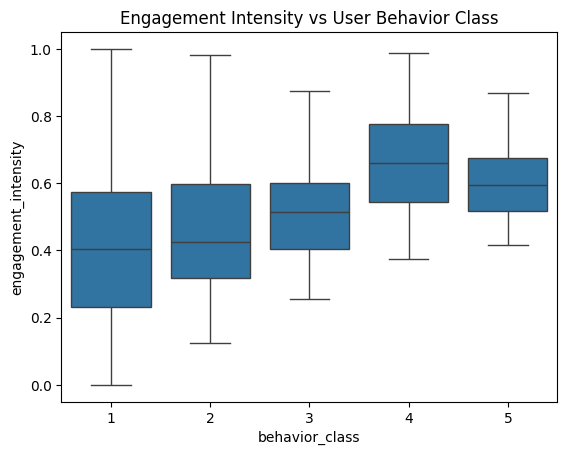

In [20]:
#eda

import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x='behavior_class', y='engagement_intensity', data=data)
plt.title("Engagement Intensity vs User Behavior Class")
plt.show()



In [22]:
#EARLY WARNING SIGNALS (usres at risk of disengamgeenet)

warning_users = data[
    (data['engagement_intensity'] < 0.4) &
    (data['resource_stress'] > 0.6)
]

warning_users.head()


,user_id,device_model,os,app_usage_min,screen_on_hours,battery_drain,apps_installed,data_usage_mb,age,gender,behavior_class,engagement_intensity,resource_stress,app_overload
35,36,Samsung Galaxy S21,Android,0.003521,0.018182,0.103307,0.101124,0.021294,20,Female,1,0.172079,0.935513,0.924997
73,74,Xiaomi Mi 11,Android,0.001761,0.009091,0.105165,0.011236,0.044259,50,Female,1,0.196049,0.983221,0.456537
76,77,Xiaomi Mi 11,Android,0.007042,0.090909,0.095132,0.044944,0.008351,54,Female,1,0.019151,0.825945,0.570115
163,164,iPhone 12,iOS,0.003521,0.090909,0.062059,0.089888,0.015449,22,Male,1,0.003331,0.713672,0.863811
167,168,Google Pixel 5,Android,0.008803,0.045455,0.061315,0.000000,0.023382,58,Male,1,0.119345,0.629676,0.323329


In [19]:
#decay ratio
feature_trend['decay_ratio'] = (
    feature_trend['last_week_usage'] / feature_trend['first_week_usage']
)


In [20]:
#classify features
def classify_feature(row):
    if row['decay_ratio'] < 0.5:
        return 'Abandoned'
    elif row['decay_ratio'] < 0.9:
        return 'Declining'
    else:
        return 'Adopted'

feature_trend['feature_status'] = feature_trend.apply(classify_feature, axis=1)


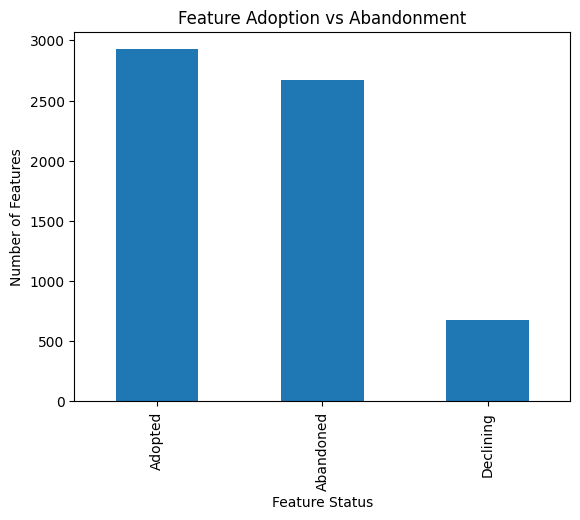

In [21]:
#visuLze
feature_trend['feature_status'].value_counts().plot(kind='bar')
plt.title("Feature Adoption vs Abandonment")
plt.xlabel("Feature Status")
plt.ylabel("Number of Features")
plt.show()


In [22]:
#FEATURE USAGE VISUALIZATION
# top_features = feature_usage.head(10)

# plt.figure(figsize=(8,5))
# sns.barplot(x='user_count', y='feature', data=top_features)
# plt.title("Top Adopted Features")
# plt.xlabel("Number of Users")
# plt.ylabel("Feature")
# plt.show()



In [14]:
#simple cluterin
from sklearn.cluster import KMeans

X = features[['avg_activity', 'active_weeks']]
kmeans = KMeans(n_clusters=2, random_state=0)
features['cluster'] = kmeans.fit_predict(X)

features.head()


,id_student,avg_activity,max_activity,active_weeks,cluster
0,6516,69.615385,229,39,0
1,8462,37.823529,153,17,0
2,11391,34.148148,183,27,0
3,23629,13.909091,35,11,0
4,23698,32.814815,132,27,0
